# Danh gia Cross-dataset Celeb-DF v2 -- rPPG-only (DeepPhysCAN_v2) (eval-only, KHONG train/fine-tune)

Load checkpoint rPPG-only (DeepPhysCAN_v2) da train tren FF++ C23, chay zero-shot qua cache
Celeb-DF v2 (100 frames). Day la 1 trong 2 hang "ablation" (cung Spatial-only) de so sanh voi
CAN-fusion -- bang chung cho cau hoi "fusion co thuc su giup tong quat hoa tot hon khong".

## Kaggle Input can add
1. `celebdf-v2-rppg-cache` (cache 100 frames -- chay `prepare-data-celebdf-v2-rppg.ipynb` truoc)
2. Checkpoint rPPG-only da train (`rppg_can_best.pth`)

In [1]:
import os, glob, random, json
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings("ignore")

CELEBDF_CACHE_DIR = "/kaggle/input/datasets/thinhphan1506/celebdf-v2-rppg-cache/celebdf_v2_rppg_cache"   # SUA path dung
CELEBDF_MANIFEST  = os.path.join(CELEBDF_CACHE_DIR, "manifest_processed.csv")
BEST_PATH = "/kaggle/input/datasets/thinhphan272/trained-dffusionmodel-rppg-pth/rppg_can_branch/rppg_can_best.pth"   # SUA dung checkpoint

# Tu dong dieu chinh path neu mount o vi tri khac
if not os.path.exists(CELEBDF_MANIFEST):
    for alt in ["/kaggle/input/celebdf-v2-rppg-cache",
                "/kaggle/input/celebdf-v2-rppg-cache/celebdf_v2_rppg_cache",
                "./celebdf_v2_rppg_cache"]:
        cand = os.path.join(alt, "manifest_processed.csv")
        if os.path.exists(cand):
            CELEBDF_CACHE_DIR = alt; CELEBDF_MANIFEST = cand; break

assert os.path.isdir(CELEBDF_CACHE_DIR), f"Khong tim thay: {CELEBDF_CACHE_DIR}"
assert os.path.exists(CELEBDF_MANIFEST), f"Khong tim thay: {CELEBDF_MANIFEST}"
assert os.path.exists(BEST_PATH), f"Khong tim thay checkpoint: {BEST_PATH}"

# PHAI KHOP voi luc train rPPG v3
CAN_IMG_SIZE   = 96
CLIP_LEN_EVAL  = 96
DIFF_EPS       = 0.01
DROPOUT        = 0.3
TTA_USED       = "hflip+half_clip"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OUT_DIR = "/kaggle/working/rppg_celebdf_eval"
os.makedirs(OUT_DIR, exist_ok=True)
print("Device:", DEVICE)

Device: cuda


## 1. Doc manifest Celeb-DF v2

In [2]:
def resolve_frame_dir(row, cache_dir):
    orig = str(row.out_dir)
    if os.path.isdir(orig) and len(glob.glob(os.path.join(orig, "*.jpg"))) > 0:
        return orig

    sub = "real" if row.label == 0 else f"fake_{row.method}"

    cand1 = os.path.join(cache_dir, str(row.split), sub, str(row.video_id))
    if os.path.isdir(cand1) and len(glob.glob(os.path.join(cand1, "*.jpg"))) > 0:
        return cand1

    cand2 = os.path.join(cache_dir, sub, str(row.video_id))
    if os.path.isdir(cand2) and len(glob.glob(os.path.join(cand2, "*.jpg"))) > 0:
        return cand2

    orig_norm = orig.replace("\\", "/")
    for marker in ["/test/", "/celebdf_v2_rppg_cache/", "/celebdf_v2_cache/"]:
        if marker in orig_norm:
            rel = orig_norm.split(marker, 1)[1]
            cand = os.path.join(cache_dir, marker.strip("/"), rel)
            if os.path.isdir(cand) and len(glob.glob(os.path.join(cand, "*.jpg"))) > 0:
                return cand
            cand_d = os.path.join(cache_dir, rel)
            if os.path.isdir(cand_d) and len(glob.glob(os.path.join(cand_d, "*.jpg"))) > 0:
                return cand_d

    cand3 = os.path.join(cache_dir, str(row.video_id))
    if os.path.isdir(cand3) and len(glob.glob(os.path.join(cand3, "*.jpg"))) > 0:
        return cand3

    return cand1

manifest = pd.read_csv(CELEBDF_MANIFEST)
manifest = manifest[manifest["status"].isin(["ok", "skip_exists", "partial"])].reset_index(drop=True)
test_df = manifest.copy()
test_df["out_dir"] = [resolve_frame_dir(row, CELEBDF_CACHE_DIR) for row in test_df.itertuples()]

valid_count = sum(
    1 for d in test_df["out_dir"]
    if os.path.isdir(d) and len(glob.glob(os.path.join(d, "*.jpg"))) > 0
)
print(f"Test videos (Celeb-DF v2): {len(test_df)}")
print(f"So video tim thay anh hop le tren dia: {valid_count} / {len(test_df)}")

if valid_count == 0:
    print(f"\nCANH BAO: Khong tim thay anh nao tai CELEBDF_CACHE_DIR: {CELEBDF_CACHE_DIR}")
    if os.path.isdir(CELEBDF_CACHE_DIR):
        print("Cau truc thuc te:")
        for item in os.listdir(CELEBDF_CACHE_DIR)[:10]:
            print("  -", item)

assert valid_count > 0, (
    f"Khong tim thay khung hinh nao trong {CELEBDF_CACHE_DIR}! "
    "Kiem tra lai dataset celebdf-v2-rppg-cache tren Kaggle."
)
print(test_df.groupby(["label", "method"])["video_id"].count())

Test videos (Celeb-DF v2): 518
So video tim thay anh hop le tren dia: 518 / 518
label  method         
0      original           178
1      Celeb-synthesis    340
Name: video_id, dtype: int64


## 2. Dataset (CANCelebDFEvalDataset -- appearance/motion diff)

In [3]:
def load_and_resize(path, size=CAN_IMG_SIZE):
    img = cv2.imread(path)
    if img is None:
        return np.zeros((size, size, 3), dtype=np.float32)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, (size, size)).astype(np.float32)


def compute_normalized_diff(curr, prev, eps=DIFF_EPS):
    c = curr / 255.0; p = prev / 255.0
    return (c - p) / (c + p + eps)


class CANCelebDFEvalDataset(Dataset):
    def __init__(self, df, clip_len=CLIP_LEN_EVAL, img_size=CAN_IMG_SIZE):
        self.rows = []
        for row in df.itertuples():
            ff = sorted(glob.glob(os.path.join(row.out_dir, "*.jpg")))
            if len(ff) >= 2:
                self.rows.append((row.video_id, ff, row.label, row.method))
        self.clip_len = clip_len
        self.img_size = img_size

    def __len__(self): return len(self.rows)

    def __getitem__(self, idx):
        vid_id, paths, label, method = self.rows[idx]
        n = len(paths)
        need = self.clip_len + 1
        start = max(0, (n - need) // 2)
        apps, mots, prev = [], [], None
        for i in range(min(need, n)):
            img = load_and_resize(paths[min(start + i, n - 1)], self.img_size)
            if prev is not None:
                apps.append(img / 255.0)
                mots.append(compute_normalized_diff(img, prev))
            prev = img
        while len(apps) < self.clip_len:
            apps.append(apps[-1] if apps else np.zeros((self.img_size, self.img_size, 3), dtype=np.float32))
            mots.append(mots[-1] if mots else np.zeros((self.img_size, self.img_size, 3), dtype=np.float32))
        app_t = torch.from_numpy(np.stack(apps[:self.clip_len])).permute(0, 3, 1, 2).float()
        mot_t = torch.from_numpy(np.stack(mots[:self.clip_len])).permute(0, 3, 1, 2).float()
        return app_t, mot_t, torch.tensor(label, dtype=torch.float32), method, vid_id


test_ds = CANCelebDFEvalDataset(test_df)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
assert len(test_ds) > 0, "LOI: test_ds co 0 video hop le!"
print(f"Test videos hop le: {len(test_ds)}")

Test videos hop le: 518


## 3. Kien truc DeepPhysCAN_v2 (copy nguyen xi tu train-dffusionmodel-rppg)

In [4]:
class SqueezeExcitation(nn.Module):
    def __init__(self, ch, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(ch, ch // reduction), nn.ReLU(),
            nn.Linear(ch // reduction, ch), nn.Sigmoid())
    def forward(self, x):
        return x * self.fc(x).unsqueeze(-1).unsqueeze(-1)


class ResConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, use_se=False):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch))
        self.se = SqueezeExcitation(out_ch) if use_se else nn.Identity()
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.relu(self.se(self.conv(x)) + self.shortcut(x))


class AttentionMask(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.conv = nn.Sequential(nn.Conv2d(in_ch, 1, 1), nn.Sigmoid())
    def forward(self, x):
        return self.conv(x)


class TemporalTransformer(nn.Module):
    def __init__(self, dim, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim) * 0.02)
        self.pos_drop  = nn.Dropout(dropout)
        encoder_layer  = nn.TransformerEncoderLayer(
            d_model=dim, nhead=n_heads, dim_feedforward=dim * 2,
            dropout=dropout, activation="gelu", batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.norm    = nn.LayerNorm(dim)
    def forward(self, x):
        B = x.shape[0]
        x = torch.cat([self.cls_token.expand(B, -1, -1), x], dim=1)
        return self.norm(self.encoder(self.pos_drop(x))[:, 0])


class DeepPhysCAN_v2(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.app_block1 = ResConvBlock(3, 48);   self.att_mask1 = AttentionMask(48)
        self.app_block2 = ResConvBlock(48, 96);  self.att_mask2 = AttentionMask(96)
        self.app_block3 = ResConvBlock(96, 192, use_se=True);  self.att_mask3 = AttentionMask(192)
        self.app_block4 = ResConvBlock(192, 256, use_se=True); self.att_mask4 = AttentionMask(256)
        self.mot_block1 = ResConvBlock(3, 48)
        self.mot_block2 = ResConvBlock(48, 96)
        self.mot_block3 = ResConvBlock(96, 192, use_se=True)
        self.mot_block4 = ResConvBlock(192, 256, use_se=True)
        self.pool = nn.AvgPool2d(2, 2)
        self.gap  = nn.AdaptiveAvgPool2d(1)
        self.frame_feat = nn.Sequential(nn.Linear(256, 256), nn.GELU(), nn.Dropout(dropout))
        self.temporal   = TemporalTransformer(dim=256, n_heads=4, n_layers=2, dropout=dropout)
        self.classifier = nn.Sequential(
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(dropout), nn.Linear(128, 1))
        self.embed_dim = 256

    def _forward_pair(self, app, mot):
        a1 = self.app_block1(app); m1 = self.att_mask1(a1); a1 = self.pool(a1)
        a2 = self.app_block2(a1);  m2 = self.att_mask2(a2); a2 = self.pool(a2)
        a3 = self.app_block3(a2);  m3 = self.att_mask3(a3); a3 = self.pool(a3)
        a4 = self.app_block4(a3);  m4 = self.att_mask4(a4)
        v1 = self.mot_block1(mot) * m1; v1 = self.pool(v1)
        v2 = self.mot_block2(v1)  * m2; v2 = self.pool(v2)
        v3 = self.mot_block3(v2)  * m3; v3 = self.pool(v3)
        v4 = self.mot_block4(v3)  * m4
        return self.frame_feat(self.gap(v4).flatten(1))

    def forward_features(self, app_clip, mot_clip):
        B, T = app_clip.shape[:2]
        app_flat = app_clip.reshape(B * T, *app_clip.shape[2:])
        mot_flat = mot_clip.reshape(B * T, *mot_clip.shape[2:])
        CHUNK = 64
        if app_flat.shape[0] <= CHUNK:
            feats = self._forward_pair(app_flat, mot_flat)
        else:
            parts = []
            for i in range(0, app_flat.shape[0], CHUNK):
                parts.append(self._forward_pair(app_flat[i:i+CHUNK], mot_flat[i:i+CHUNK]))
            feats = torch.cat(parts, dim=0)
        return self.temporal(feats.reshape(B, T, -1))

    def forward(self, app_clip, mot_clip):
        return self.classifier(self.forward_features(app_clip, mot_clip)).squeeze(-1)

model = DeepPhysCAN_v2().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"DeepPhysCAN_v2: {n_params/1e6:.2f}M params | embed_dim={model.embed_dim}")

DeepPhysCAN_v2: 4.76M params | embed_dim=256


## 4. Ham metric (copy nguyen xi, dong bo du an)

In [5]:
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, confusion_matrix
from scipy.optimize import brentq
from scipy.interpolate import interp1d

def calc_eer(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    return brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)

def find_eer_threshold(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    fnr = 1 - tpr
    return float(thresholds[int(np.nanargmin(np.abs(fnr - fpr)))])

def calc_far_frr(y_true, y_score, threshold):
    y_true = np.asarray(y_true)
    y_pred = (np.asarray(y_score) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    far = fn / (fn + tp) if (fn + tp) > 0 else float("nan")   # fake -> bi doan real
    frr = fp / (fp + tn) if (fp + tn) > 0 else float("nan")   # real -> bi doan fake
    return far, frr, cm

def calc_far_frr_curve(y_true, y_score, n_points=200):
    y_true = np.asarray(y_true); y_score = np.asarray(y_score)
    thresholds = np.linspace(0.0, 1.0, n_points)
    fars, frrs = [], []
    for t in thresholds:
        far, frr, _ = calc_far_frr(y_true, y_score, threshold=t)
        fars.append(far); frrs.append(frr)
    return thresholds, np.array(fars), np.array(frrs)

def calc_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true); y_score = np.asarray(y_score)
    if len(y_true) == 0:
        raise ValueError("calc_metrics nhan mang rong (y_true co 0 mau)!")
    auc = roc_auc_score(y_true, y_score)
    eer = calc_eer(y_true, y_score)
    acc = accuracy_score(y_true, (y_score >= threshold).astype(int))
    far_05, frr_05, cm_05 = calc_far_frr(y_true, y_score, threshold=0.5)
    eer_thr = find_eer_threshold(y_true, y_score)
    far_eer, frr_eer, cm_eer = calc_far_frr(y_true, y_score, threshold=eer_thr)
    fpr, tpr, roc_thr = roc_curve(y_true, y_score)
    return {"acc": acc, "auc": auc, "eer": eer, "far_at_0.5": far_05, "frr_at_0.5": frr_05,
            "cm_at_0.5": cm_05, "eer_threshold": eer_thr, "far_at_eer": far_eer,
            "frr_at_eer": frr_eer, "cm_at_eer": cm_eer,
            "roc_fpr": fpr, "roc_tpr": tpr, "roc_thresholds": roc_thr}
print("Metric functions OK")

Metric functions OK


## 5. Load checkpoint + Danh gia zero-shot (TTA=hflip+half_clip) + ROC/FAR-FRR/Confusion Matrix

In [6]:
from tqdm import tqdm

ckpt = torch.load(BEST_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"Nap checkpoint rPPG: epoch={ckpt.get('epoch', '?')}")
if "val_metrics" in ckpt:
    print(f"  val_auc={ckpt['val_metrics'].get('auc', '?'):.4f}")


@torch.no_grad()
def evaluate_with_tta(eval_model, loader):
    y_true, y_score, methods = [], [], []
    for app_clip, mot_clip, label, method, _vid in tqdm(loader, desc="Danh gia Celeb-DF v2 (rPPG-only)"):
        app_clip, mot_clip = app_clip.to(DEVICE), mot_clip.to(DEVICE)
        logits_list = [eval_model(app_clip, mot_clip)]
        # TTA 1: horizontal flip
        logits_list.append(eval_model(
            torch.flip(app_clip, dims=[4]), torch.flip(mot_clip, dims=[4])))
        # TTA 2: first half of clip
        T = app_clip.shape[1]; half = max(T // 2, 1)
        logits_list.append(eval_model(app_clip[:, :half], mot_clip[:, :half]))
        probs = torch.stack([torch.sigmoid(l) for l in logits_list]).mean()
        y_score.append(probs.item())
        y_true.append(label.item())
        methods.append(method[0])
    return np.array(y_true), np.array(y_score), np.array(methods)


y_true, y_score, methods = evaluate_with_tta(model, test_loader)
assert len(y_true) > 0, "LOI: evaluate_with_tta khong thu duoc ket qua nao!"
test_metrics = calc_metrics(y_true, y_score)

print(f"\n=== KET QUA ZERO-SHOT TREN CELEB-DF V2 -- rPPG-only (TTA={TTA_USED}) ===")
print(f"Accuracy : {test_metrics['acc']*100:.2f}%")
print(f"AUC      : {test_metrics['auc']*100:.2f}%")
print(f"EER      : {test_metrics['eer']*100:.2f}%")
print(f"FAR@0.5  : {test_metrics['far_at_0.5']*100:.2f}%  |  FRR@0.5 : {test_metrics['frr_at_0.5']*100:.2f}%")
cm = test_metrics["cm_at_0.5"]
print(f"Confusion Matrix: TN={cm[0,0]} FP={cm[0,1]} FN={cm[1,0]} TP={cm[1,1]}")

Nap checkpoint rPPG: epoch=51
  val_auc=0.9651


Danh gia Celeb-DF v2 (rPPG-only): 100%|██████████| 518/518 [02:38<00:00,  3.27it/s]


=== KET QUA ZERO-SHOT TREN CELEB-DF V2 -- rPPG-only (TTA=hflip+half_clip) ===
Accuracy : 46.53%
AUC      : 56.81%
EER      : 47.19%
FAR@0.5  : 70.00%  |  FRR@0.5 : 21.91%
Confusion Matrix: TN=139 FP=39 FN=238 TP=102


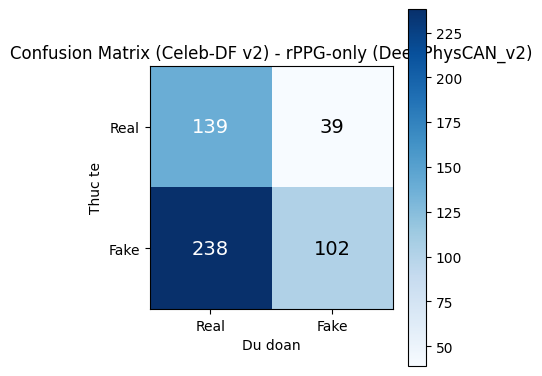

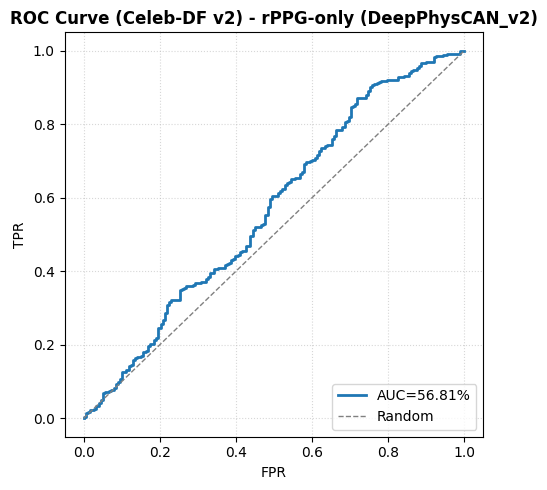

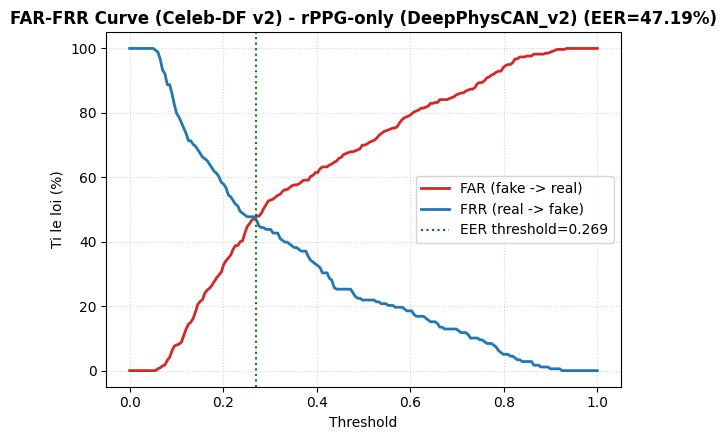


Da luu /kaggle/working/rppg_celebdf_eval/test_results_celebdf.csv
Day la hang ablation (rPPG-only) -- so sanh voi CAN-fusion va Spatial-only.
n_real=178  n_fake=340


In [7]:
import matplotlib.pyplot as plt
MODEL_NAME = "rPPG-only (DeepPhysCAN_v2)"

fig, ax = plt.subplots(figsize=(4, 4))
cm = test_metrics["cm_at_0.5"]
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Real", "Fake"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Real", "Fake"])
ax.set_xlabel("Du doan"); ax.set_ylabel("Thuc te")
ax.set_title(f"Confusion Matrix (Celeb-DF v2) - {MODEL_NAME}")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=14)
plt.colorbar(im); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "confusion_matrix_celebdf.png"), dpi=100); plt.show()

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(test_metrics["roc_fpr"], test_metrics["roc_tpr"], lw=2, color="#1f77b4",
        label=f"AUC={test_metrics['auc']*100:.2f}%")
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Random")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title(f"ROC Curve (Celeb-DF v2) - {MODEL_NAME}", fontweight="bold")
ax.legend(loc="lower right"); ax.grid(True, ls=":", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "roc_curve_celebdf.png"), dpi=150); plt.show()

thr, fars, frrs = calc_far_frr_curve(y_true, y_score)
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(thr, fars * 100, lw=2, color="#d62728", label="FAR (fake -> real)")
ax.plot(thr, frrs * 100, lw=2, color="#1f77b4", label="FRR (real -> fake)")
ax.axvline(test_metrics["eer_threshold"], color="green", ls=":",
           label=f"EER threshold={test_metrics['eer_threshold']:.3f}")
ax.set_xlabel("Threshold"); ax.set_ylabel("Ti le loi (%)")
ax.set_title(f"FAR-FRR Curve (Celeb-DF v2) - {MODEL_NAME} (EER={test_metrics['eer']*100:.2f}%)",
             fontweight="bold")
ax.legend(); ax.grid(True, ls=":", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "far_frr_curve_celebdf.png"), dpi=150); plt.show()

result_row = {
    "model": MODEL_NAME, "dataset": "CelebDF-v2", "tta_used": TTA_USED,
    "n_real": int((methods == "original").sum()),
    "n_fake": int((methods == "Celeb-synthesis").sum()),
    "acc": test_metrics["acc"], "auc": test_metrics["auc"], "eer": test_metrics["eer"],
    "far_at_0.5": test_metrics["far_at_0.5"], "frr_at_0.5": test_metrics["frr_at_0.5"],
    "tn": int(cm[0,0]), "fp": int(cm[0,1]), "fn": int(cm[1,0]), "tp": int(cm[1,1]),
    "notes": "zero-shot, checkpoint train tren FF++ C23, khong fine-tune tren Celeb-DF",
}
pd.DataFrame([result_row]).to_csv(os.path.join(OUT_DIR, "test_results_celebdf.csv"), index=False)
print(f"\nDa luu {OUT_DIR}/test_results_celebdf.csv")
print("Day la hang ablation (rPPG-only) -- so sanh voi CAN-fusion va Spatial-only.")
print(f"n_real={result_row['n_real']}  n_fake={result_row['n_fake']}")